# Next-Word Prediction: Exploratory Data Analysis

Explores the **SwiftKey / HC Corpora** dataset to understand the data and guide modelling choices.

The notebook loads, cleans, and tokenizes the corpus, then analyzes **corpus size, sentence lengths, word-frequency distribution, and vocabulary coverage**.

Build the corpus first with `python scripts/download_data.py`. It downloads and prepares the ~560 MB archive into `data/raw/corpus.txt`.

See the project README for setup details and options for using your own text.


## 1. Setup

In [1]:
%matplotlib inline
import os
import sys
sys.path.append(os.path.abspath(".."))  # so `import config` and `from src...` work from notebooks/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src.dataset import load_corpus, prepare_data
from src.preprocess import Vocabulary, clean_text, split_sentences, tokenize

np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("Corpus:", config.DEFAULT_CORPUS)
print("Outputs:", config.OUTPUTS_DIR)

Corpus: C:\Users\User\Downloads\next-word-prediction (3)\next-word-prediction-main\data\raw\corpus.txt
Outputs: C:\Users\User\Downloads\next-word-prediction (3)\next-word-prediction-main\outputs


## 2. Load and inspect the raw text

In [2]:
raw = load_corpus()
print(f"{len(raw):,} characters")
print(raw[3000:3400])

7,551,350 characters
 going to do this can you do me a favor and make it more sooner than later
I saw dude at the movies working. That's cool. Have to make money somehow. I should apply there
What's your high/low bowling score? Getting ready to walk into the lanes.
I'm not a gusher. When I review beers or discuss breweries, I try to temper my praise so I don't sound like a fanboy. If beer bloggers aren't careful, they


## 3. Sentences and tokens

`split_sentences` strips the Gutenberg header and footer, splits on sentence punctuation and blank lines, and tokenizes each sentence to lowercase words.

In [3]:
sentences = split_sentences(raw)
lengths = np.array([len(s) for s in sentences])
all_tokens = [t for s in sentences for t in s]

summary = pd.Series({
    "sentences": len(sentences),
    "tokens": len(all_tokens),
    "unique words": len(set(all_tokens)),
    "mean sentence length": round(lengths.mean(), 1),
    "median sentence length": int(np.median(lengths)),
    "95th percentile length": int(np.percentile(lengths, 95)),
    "longest sentence": int(lengths.max()),
})
summary

sentences                   90279.0
tokens                    1309094.0
unique words                57920.0
mean sentence length           14.5
median sentence length         12.0
95th percentile length         35.0
longest sentence              213.0
dtype: float64

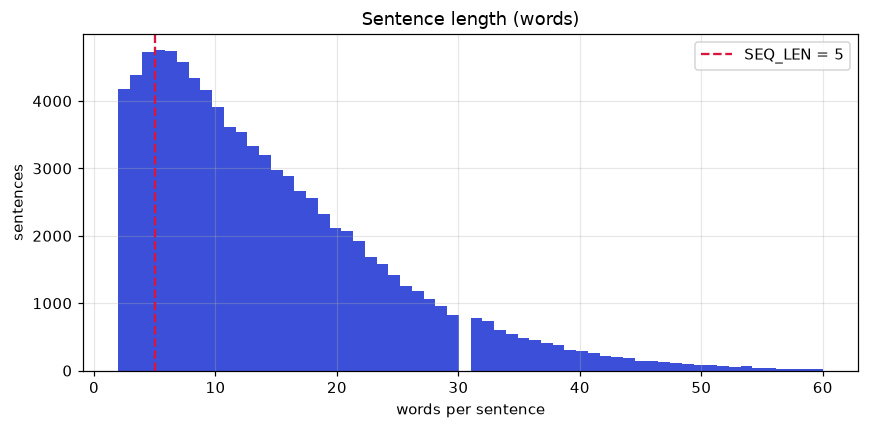

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths[lengths <= 60], bins=60, color="#3b4fd8")
ax.axvline(config.SEQ_LEN, color="crimson", ls="--", label=f"SEQ_LEN = {config.SEQ_LEN}")
ax.set(title="Sentence length (words)", xlabel="words per sentence", ylabel="sentences")
ax.legend()
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "eda_sentence_lengths.png")
plt.show()

## 4. Most frequent words

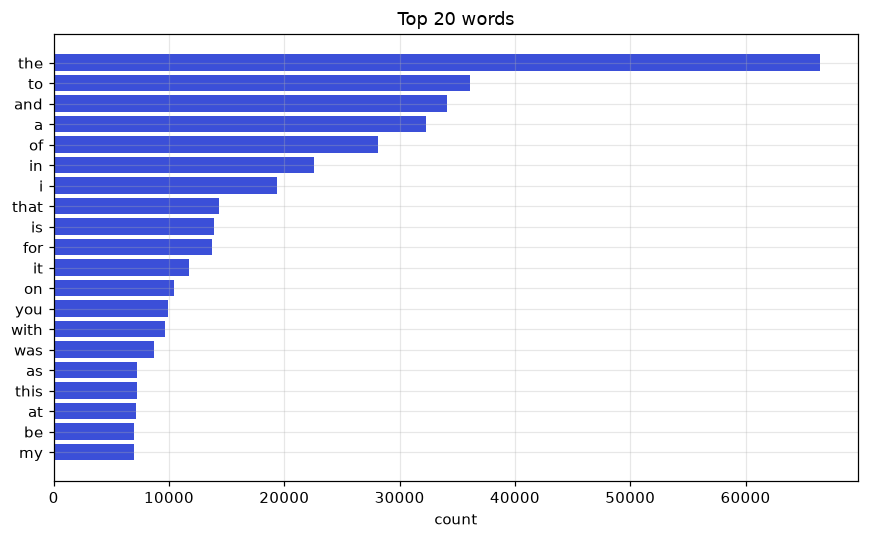

In [6]:
from collections import Counter

counts = Counter(all_tokens)
top = pd.DataFrame(counts.most_common(20), columns=["word", "count"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["word"][::-1], top["count"][::-1], color="#3b4fd8")
ax.set(title="Top 20 words", xlabel="count")
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "eda_top_words.png")
plt.show()

## 5. Zipf's law

Word frequency falls off as a power law: a handful of words are extremely common and most words are rare. This is why a small vocabulary still covers most of the text, and why the rare tail becomes `<unk>`.

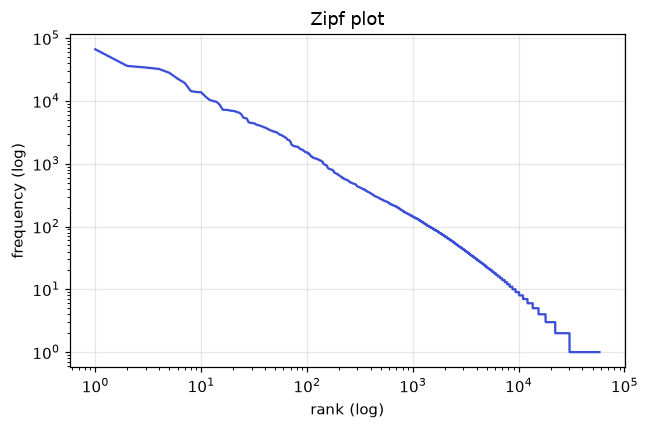

In [7]:
freqs = np.array(sorted(counts.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(ranks, freqs, color="#3b4fd8")
ax.set(title="Zipf plot", xlabel="rank (log)", ylabel="frequency (log)")
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "eda_zipf.png")
plt.show()

## 6. Vocabulary size vs. coverage

How much of the running text is covered if we keep only the top-N words?

In [8]:
cum_cov = np.cumsum(freqs) / freqs.sum()
rows = []
for n in [500, 1000, 2000, 5000, 10000]:
    if n <= len(cum_cov):
        rows.append({"vocab size": n, "token coverage": f"{cum_cov[n - 1]:.1%}"})
pd.DataFrame(rows)

,vocab size,token coverage
0,500,62.9%
1,1000,70.5%
2,2000,78.1%
3,5000,87.0%
4,10000,92.3%


In [9]:
kept = sum(1 for c in counts.values() if c >= config.MIN_FREQ)
print(f"Words seen at least {config.MIN_FREQ}x: {kept:,} of {len(counts):,} unique words")
print(f"Effective vocabulary (MAX_VOCAB={config.MAX_VOCAB:,}): {min(kept, config.MAX_VOCAB - 2) + 2:,} including <pad> and <unk>")

Words seen at least 2x: 30,210 of 57,920 unique words
Effective vocabulary (MAX_VOCAB=10,000): 10,000 including <pad> and <unk>


## 7. Takeaways

- The vocabulary is small enough for a full softmax over every word, so no sampled softmax is needed.
- Most sentences are short, so a context window of `SEQ_LEN` words captures nearly all the usable history, and left padding with `<pad>` (masked in the model) handles the shorter ones.
- Rare words map to `<unk>`. The predictor never suggests `<unk>` or `<pad>`.

Next: `02_preprocessing.ipynb`.